
**Assignment** **4**

**Question** : Select any EEG signals dataset from any open source with atleast 10k sample points.
Calculate its fractal dimension by box counting method

**What is Fractal Dimension?**

A fractal dimension is a measure that characterizes how completely a fractal appears to fill space as you zoom in on it. For time series data like EEG signals, fractal dimensions help quantify the complexity or self-similarity of the signal.

**What is the Box-Counting Method?**

The box-counting method is one of the most widely used methods to compute the fractal dimension of a time series. In this method, the signal is "covered" with boxes of varying sizes, and the number of non-empty boxes is counted at each size. The fractal dimension is then estimated by examining how the number of non-empty boxes scales as the box size changes.

Mathematically, the fractal dimension D is calculated using the formula:

𝐷 = lim (𝜖 → 0)  (log(𝑁(𝜖))) / (log(1/𝜖))

Where:
N(ϵ) is the number of boxes of size ϵ required to cover the object.

ϵ is the size of the box.

By plotting log(N(ϵ)) against log⁡(1/𝜖) and computing the slope of the line, we can estimate the fractal dimension.

The data are collected from ten students, each watching ten videos. Therefore, it can be seen as only 100 data points for these 12000+ rows. then each data point consists of 120+ rows, which is sampled every 0.5 seconds (so each data point is a one minute video). Signals with higher frequency are reported as the mean value during each 0.5 second.

EEG_data.csv: Contains the EEG data recorded from 10 students

video data : Each video lasts roughly two-minute long, removed the first 30 seconds and last 30 seconds, only collected the EEG data during the middle 1 minute.

To calculate the fractal dimension of the EEG signal, I used the box-counting method.

Here, I have selected the "Raw" EEG signal from the dataset as the data to analyze.

In [14]:
import pandas as pd

# Load the CSV file
file_path = '/content/EEG_data.csv'
eeg_data = pd.read_csv(file_path)

# Displaying the first few rows of the dataset
eeg_data.head()


,SubjectID,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,predefinedlabel,user-definedlabeln
0,0.0,0.0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0
1,0.0,0.0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0
2,0.0,0.0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0
3,0.0,0.0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0
4,0.0,0.0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0


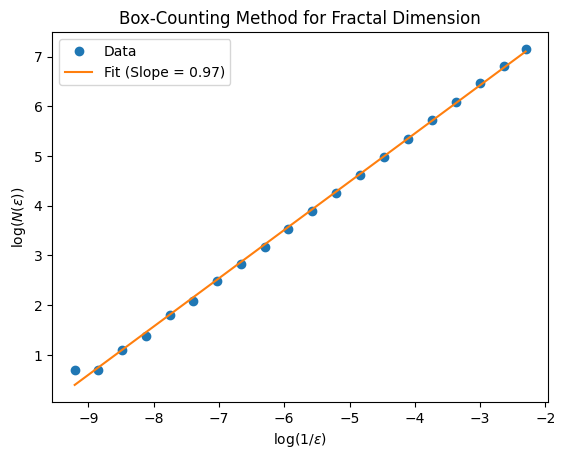

Fractal Dimension: 0.9711012024190806


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extracting the 'Raw' EEG signal column for the fractal dimension calculation
eeg_signal = eeg_data['Raw'].values

# Box counting function
def box_counting(data, box_sizes):
    counts = []
    for size in box_sizes:
        # Break the time series into boxes of the current size
        num_boxes = int(np.ceil(len(data) / size))
        boxes = [data[i * size:(i + 1) * size] for i in range(num_boxes)]

        # Checking if the box contains any part of the signal (non-empty)
        non_empty_boxes = sum([np.max(box) != np.min(box) for box in boxes])
        counts.append(non_empty_boxes)

    return counts

# Fractal dimension calculation using the box-counting method
def fractal_dimension_box_counting(data):
    box_sizes = np.logspace(1, 4, num=20, dtype=int)  # Range of box sizes
    counts = box_counting(data, box_sizes)

    # Performing linear regression on log-log scale
    log_sizes = np.log(1 / box_sizes)
    log_counts = np.log(counts)
    coeffs = np.polyfit(log_sizes, log_counts, 1)  # Linear fit

    # The slope of the line gives the fractal dimension
    fractal_dimension = coeffs[0]

    # Plot the box-counting results
    plt.plot(log_sizes, log_counts, 'o', label="Data")
    plt.plot(log_sizes, np.polyval(coeffs, log_sizes), label=f"Fit (Slope = {fractal_dimension:.2f})")
    plt.xlabel(r"$\log(1/\epsilon)$")
    plt.ylabel(r"$\log(N(\epsilon))$")
    plt.title("Box-Counting Method for Fractal Dimension")
    plt.legend()
    plt.show()

    return fractal_dimension

# Calculating the fractal dimension for the 'Raw' EEG signal
fd = fractal_dimension_box_counting(eeg_signal)
print(f"Fractal Dimension: {fd}")



A fractal dimension is approximately 0.97 suggests that the EEG signal from the dataset is fairly smooth and regular, indicating the low complexity in the brain activity.


In EEG analysis:
Fractal Dimension Around 1: A value close to 1, such as 0.97, points to predictable and less chaotic brain activity. This can be associated with states of relaxation, rest, or minimal cognitive engagement.

Higher Fractal Dimension (Closer to 2): More irregular and complex signals are often linked to active cognitive tasks, problem-solving, or conditions like epilepsy.
In this case, the fractal dimension of 0.97 suggests that the recorded brain activity was relatively stable, possibly indicating a calm or resting state during the measurement

Source of dataset: https://www.kaggle.com/datasets/wanghaohan/confused-eeg?select=EEG_data.csv